**به نام خدا**

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/gtsrb-german-traffic-sign


In [26]:
import os
import pandas as pd
import numpy as np

In [5]:
os.listdir(path)

['Meta',
 'meta',
 'Meta.csv',
 'Train.csv',
 'Test.csv',
 'Test',
 'test',
 'Train',
 'train']

### dataset info

In [6]:
csv_path = os.path.join(path,"Train.csv")

In [33]:
df = pd.read_csv(csv_path)
df

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png
...,...,...,...,...,...,...,...,...
39204,52,56,5,6,47,51,42,Train/42/00042_00007_00025.png
39205,56,58,5,5,51,53,42,Train/42/00042_00007_00026.png
39206,58,62,5,6,53,57,42,Train/42/00042_00007_00027.png
39207,63,69,5,7,58,63,42,Train/42/00042_00007_00028.png


In [38]:
class_counts = df['ClassId'].value_counts()
print("\n📊 Class Distribution:")
print(class_counts)


📊 Class Distribution:
ClassId
2     2250
1     2220
13    2160
12    2100
38    2070
10    2010
4     1980
5     1860
25    1500
9     1470
7     1440
3     1410
8     1410
11    1320
35    1200
18    1200
17    1110
14     780
31     780
33     689
15     630
26     600
28     540
23     510
30     450
6      420
16     420
34     420
22     390
36     390
20     360
40     360
21     330
39     300
29     270
24     270
42     240
32     240
27     240
41     240
0      210
19     210
37     210
Name: count, dtype: int64


In [35]:
print("\n📏 Image Dimensions Stats:")
print(f"Avg Width: {df['Width'].mean():.1f} ± {df['Width'].std():.1f}")
print(f"Avg Height: {df['Height'].mean():.1f} ± {df['Height'].std():.1f}")
print(f"Min Width: {df['Width'].min()}, Max Width: {df['Width'].max()}")
print(f"Min Height: {df['Height'].min()}, Max Height: {df['Height'].max()}")


📏 Image Dimensions Stats:
Avg Width: 50.8 ± 24.3
Avg Height: 50.3 ± 23.1
Min Width: 25, Max Width: 243
Min Height: 25, Max Height: 225


In [36]:
df['Roi_Width'] = df['Roi.X2'] - df['Roi.X1']
df['Roi_Height'] = df['Roi.Y2'] - df['Roi.Y1']

print("\n🔳 Bounding Box (ROI) Stats:")
print(f"Avg ROI Width: {df['Roi_Width'].mean():.1f} ± {df['Roi_Width'].std():.1f}")
print(f"Avg ROI Height: {df['Roi_Height'].mean():.1f} ± {df['Roi_Height'].std():.1f}")
print(f"Smallest ROI: {df['Roi_Width'].min()}x{df['Roi_Height'].min()}")
print(f"Largest ROI: {df['Roi_Width'].max()}x{df['Roi_Height'].max()}")


🔳 Bounding Box (ROI) Stats:
Avg ROI Width: 39.2 ± 21.8
Avg ROI Height: 38.8 ± 20.8
Smallest ROI: 15x15
Largest ROI: 203x185


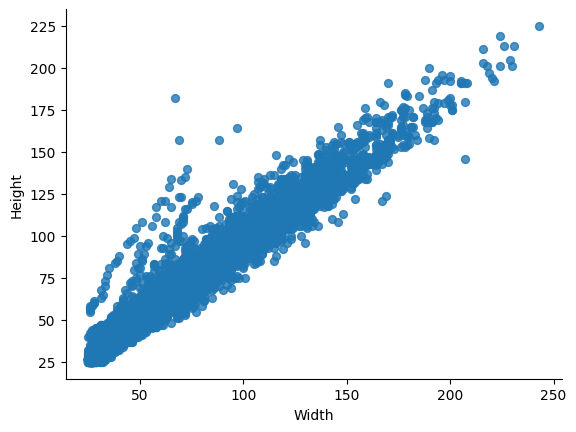

In [37]:
from matplotlib import pyplot as plt
df.plot(kind='scatter', x='Width', y='Height', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

In [13]:
train_add = os.path.join(path,"train")

In [20]:
info = []
for i in os.listdir(train_add):
  _path = os.path.join(train_add, i)
  info.append((i,len(os.listdir(_path))))

In [27]:
counts = [count for (_, count) in info]

stats = {
    "Total directories": len(counts),
    "Total files": sum(counts),
    "Max files": max(counts),
    "Min files": min(counts),
    "Mean files": np.mean(counts),
    "Median files": np.median(counts),
    "Std deviation": np.std(counts),
    "25th percentile": np.percentile(counts, 25),
    "75th percentile": np.percentile(counts, 75),
}

print("📊 Directory Statistics:")
for key, value in stats.items():
    print(f"{key}: {value:.2f}" if isinstance(value, float) else f"{key}: {value}")

📊 Directory Statistics:
Total directories: 43
Total files: 39209
Max files: 2250
Min files: 210
Mean files: 911.84
Median files: 600.00
Std deviation: 687.72
25th percentile: 345.00
75th percentile: 1425.00


In [29]:
max_dir = max(info, key=lambda x: x[1])
min_dir = min(info, key=lambda x: x[1])

print(f"\n🔝 Most files: '{max_dir[0]}' ({max_dir[1]} files)")
print(f"🔙 Least files: '{min_dir[0]}' ({min_dir[1]} files)")


🔝 Most files: '2' (2250 files)
🔙 Least files: '19' (210 files)


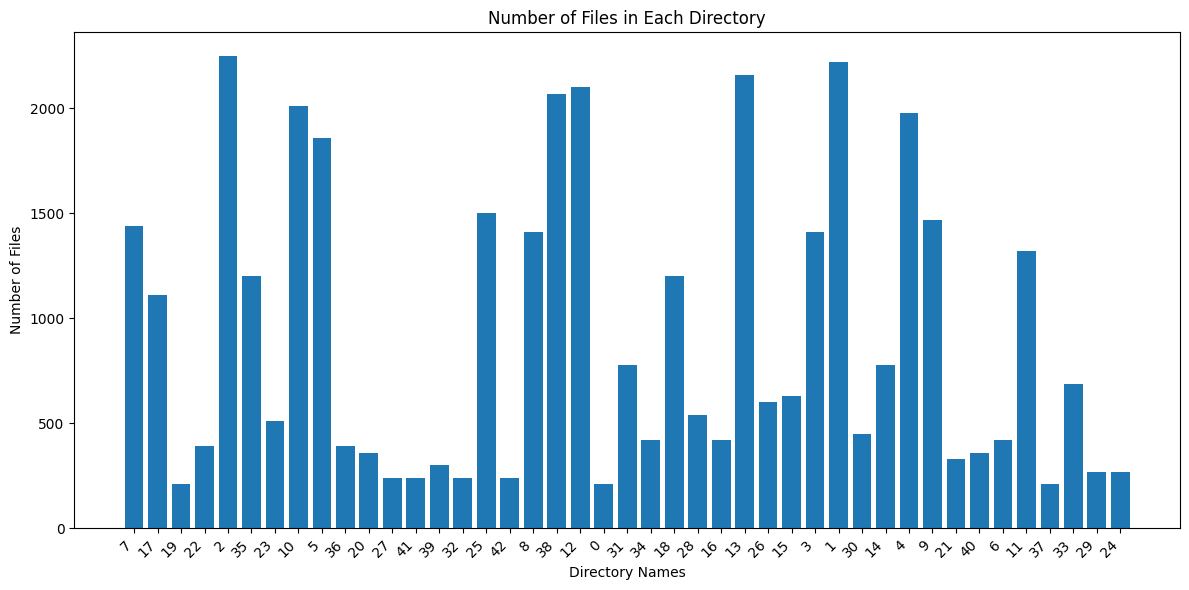

In [24]:

labels, values = zip(*info)

plt.figure(figsize=(12, 6))
plt.bar(labels, values)

plt.xlabel('Directory Names')
plt.ylabel('Number of Files')
plt.title('Number of Files in Each Directory')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### train model

In [ ]:
train_add = os.path.join(path,"train")
test_add = os.path.join(path,"test")
# os.listdir(train_add)

In [ ]:
os.listdir(test_add)

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image


In [ ]:
for i in os.listdir(train_add)[:5]:
  sub_path = os.path.join(train_add,i)
  sub_id = random.choice(os.listdir(sub_path))
  image_address = os.path.join(sub_path,sub_id)
  image = plt.imread(image_address)
  print(image.shape)
  # plt.imshow(image)
  # plt.show()
  # print(image_address)

(58, 59, 3)
(47, 46, 3)
(74, 86, 3)
(64, 72, 3)
(49, 50, 3)


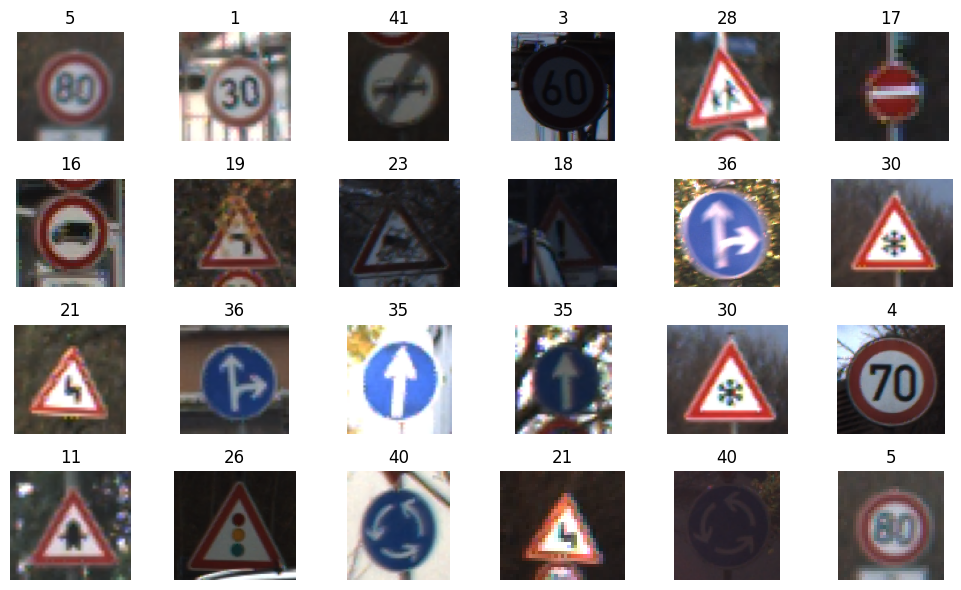

In [ ]:
plt.figure(figsize=(10,6))
for i in range(24):
    plt.subplot(4,6,i+1)
    sub_class = random.choice(os.listdir(train_add))
    sub_path = os.path.join(train_add,sub_class)
    sub_image = random.choice(os.listdir(sub_path))
    img = Image.open(os.path.join(sub_path,sub_image))

    plt.imshow(img)
    plt.title(sub_class)
    plt.axis("off")
plt.tight_layout()

In [ ]:
from torchvision import datasets, transforms

In [ ]:
data_transform_train = transforms.Compose([
    transforms.RandomEqualize(p=0.25),
    transforms.RandomRotation(degrees=(-20, 20)),
    transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5.)),
    transforms.Resize(size=(30, 30)),
    transforms.ToTensor()
])

data_transform_test = transforms.Compose([
    transforms.Resize(size=(30, 30)),
    transforms.ToTensor()
])

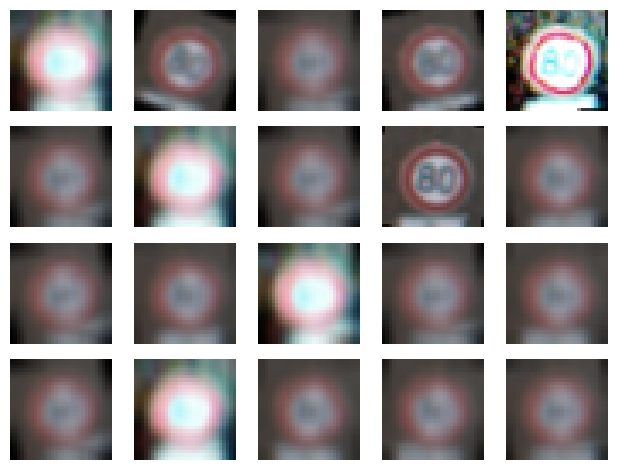

In [ ]:
transformed_image = [data_transform_train(img) for i in range(20)]

for index, image in enumerate(transformed_image):
    plt.subplot(4,5,index+1)

    plt.imshow(image.permute(1, 2, 0))
    plt.axis("off")
plt.tight_layout()

In [ ]:
import os
import matplotlib.pyplot as plt
import random
import numpy as np
from PIL import Image
import pathlib


import torch
from torch.utils.data import DataLoader,Dataset
from torchvision import datasets, transforms
from torch import nn
# from torchinfo import summary


from typing import Tuple, Dict, List

In [ ]:
def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
    class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
    return classes, class_to_idx

In [ ]:
find_classes(train_add)

In [ ]:
class GTSRBDataset(Dataset):
    def __init__(self,
                 target_dir:str,
                 transform=None) -> None:

        self.paths = list(pathlib.Path(target_dir).glob("*/*.png"))
        self.transform = transform
        self.classes, self.classes_to_idx = find_classes(target_dir)

        print(self.paths)


    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
        img = self.laod_image(index)

        class_name = self.paths[index].parent.name
        class_idx = self.classes_to_idx[class_name]

        if self.transform:
            return self.transform(img), class_idx
        else:
            return img, class_idx

    def laod_image(self, index:int) -> Image.Image:
        image_path = self.paths[index]
        return Image.open(image_path)

In [ ]:
train_data = GTSRBDataset(target_dir=train_add,
                          transform=data_transform_train)


[PosixPath('/kaggle/input/gtsrb-german-traffic-sign/train/7/00007_00041_00020.png'), PosixPath('/kaggle/input/gtsrb-german-traffic-sign/train/7/00007_00021_00024.png'), PosixPath('/kaggle/input/gtsrb-german-traffic-sign/train/7/00007_00027_00000.png'), PosixPath('/kaggle/input/gtsrb-german-traffic-sign/train/7/00007_00038_00003.png'), PosixPath('/kaggle/input/gtsrb-german-traffic-sign/train/7/00007_00001_00024.png'), PosixPath('/kaggle/input/gtsrb-german-traffic-sign/train/7/00007_00009_00002.png'), PosixPath('/kaggle/input/gtsrb-german-traffic-sign/train/7/00007_00017_00012.png'), PosixPath('/kaggle/input/gtsrb-german-traffic-sign/train/7/00007_00022_00006.png'), PosixPath('/kaggle/input/gtsrb-german-traffic-sign/train/7/00007_00034_00005.png'), PosixPath('/kaggle/input/gtsrb-german-traffic-sign/train/7/00007_00022_00022.png'), PosixPath('/kaggle/input/gtsrb-german-traffic-sign/train/7/00007_00032_00015.png'), PosixPath('/kaggle/input/gtsrb-german-traffic-sign/train/7/00007_00045_0001

In [ ]:
from torch.utils.data import DataLoader, random_split


In [ ]:
dataset_size = len(train_data)

In [ ]:
dataset_size = len(train_data)
train_size = int(0.8 * dataset_size)
test_size = dataset_size - train_size

BATCH_SIZE = 8
NUM_WORKERS = 1
_train_data, test_data = random_split(train_data, [train_size, test_size])

train_dataloader = DataLoader(dataset=_train_data,
                             batch_size=BATCH_SIZE,
                             num_workers=NUM_WORKERS,
                             shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                            batch_size=BATCH_SIZE,
                            num_workers=NUM_WORKERS,
                            shuffle=False)

In [ ]:
len(train_dataloader)

3921

In [ ]:
class TinyVGG(nn.Module):
    def __init__(self,input_shape:int,
                 hidden_unit:int,
                 output_shape:int
                 ) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,out_channels=hidden_unit,kernel_size=3,stride=1,padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_unit,out_channels=hidden_unit,kernel_size=3,stride=1,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2)
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_unit,hidden_unit,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_unit,hidden_unit,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_unit*49,
                      out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.classifier(x)
        return x

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [ ]:
model = TinyVGG(input_shape=3,
                  hidden_unit=10,
                  output_shape=len(train_data.classes)).to(device)
model

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=43, bias=True)
  )
)

In [ ]:
from torchinfo import summary

In [ ]:
# for better summary
summary(model, input_size=[1, 3,256, 256])

In [ ]:
image_batch, label_batch = next(iter(train_dataloader))
image_batch, label_batch

In [ ]:
def train_step(model:torch.nn.Module,
               dataloader:torch.utils.data.DataLoader,
               loss_fn :torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device=device):

    model.train()

    train_loss,train_acc = 0,0

    for batch, (X,y) in enumerate(dataloader):
        X, y = X.to(device),y.to(device)

        y_pred = model(X)

        loss = loss_fn(y_pred,y)
        train_loss += loss.item()


        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)

    return train_loss,train_acc

In [ ]:
def test_step(model:torch.nn.Module,
               dataloader:torch.utils.data.DataLoader,
               loss_fn :torch.nn.Module,
               device=device):

    model.eval()
    test_loss, test_acc = 0,0

    for batch, (X,y) in enumerate(dataloader):
        X, y = X.to(device),y.to(device)

        y_pred = model(X)

        loss = loss_fn(y_pred,y)
        test_loss += loss.item()

        test_label = y_pred.argmax(dim=1)
        test_acc += (test_label == y).sum().item()/len(test_label)
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)

    return test_loss,test_acc

In [ ]:
from tqdm.auto import tqdm

# 1. Take in various parameters required for training and test steps
def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):

    # 2. Create empty results dictionary
    results = {"train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    # 3. Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer)
        test_loss, test_acc = test_step(model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn)

        # 4. Print out what's happening
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        # 5. Update results dictionary
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

    # 6. Return the filled results at the end of the epochs
    return results

In [ ]:
NUM_EPOCHS = 25

model = TinyVGG(input_shape=3,
                  hidden_unit=10,
                  output_shape=len(train_data.classes)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(),
                             lr=0.001)

from timeit import default_timer as timer
start_time = timer()

model_0_results = train(model=model,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)

end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.8200 | train_acc: 0.4639 | test_loss: 1.0885 | test_acc: 0.6518
Epoch: 2 | train_loss: 0.9144 | train_acc: 0.7197 | test_loss: 0.7226 | test_acc: 0.7854
Epoch: 3 | train_loss: 0.6256 | train_acc: 0.8086 | test_loss: 0.5632 | test_acc: 0.8256
Epoch: 4 | train_loss: 0.4967 | train_acc: 0.8470 | test_loss: 0.4516 | test_acc: 0.8662
Epoch: 5 | train_loss: 0.4307 | train_acc: 0.8687 | test_loss: 0.4135 | test_acc: 0.8751
Epoch: 6 | train_loss: 0.3899 | train_acc: 0.8805 | test_loss: 0.4236 | test_acc: 0.8667
Epoch: 7 | train_loss: 0.3547 | train_acc: 0.8914 | test_loss: 0.3460 | test_acc: 0.8922
Epoch: 8 | train_loss: 0.3313 | train_acc: 0.8970 | test_loss: 0.4140 | test_acc: 0.8733
Epoch: 9 | train_loss: 0.3194 | train_acc: 0.9017 | test_loss: 0.2907 | test_acc: 0.9102
Epoch: 10 | train_loss: 0.2950 | train_acc: 0.9080 | test_loss: 0.3132 | test_acc: 0.9041
Epoch: 11 | train_loss: 0.2979 | train_acc: 0.9090 | test_loss: 0.3060 | test_acc: 0.9037
Epoch: 12 | train_l

In [ ]:
len(test_dataloader)

981

In [ ]:
def plot_loss_curves(results: Dict[str, List[float]]):
    loss = results['train_loss']
    test_loss = results['test_loss']

    accuracy = results['train_acc']
    test_accuracy = results['test_acc']

    epochs = range(len(results['train_loss']))

    plt.figure(figsize=(15, 7))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, test_accuracy, label='test_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend()

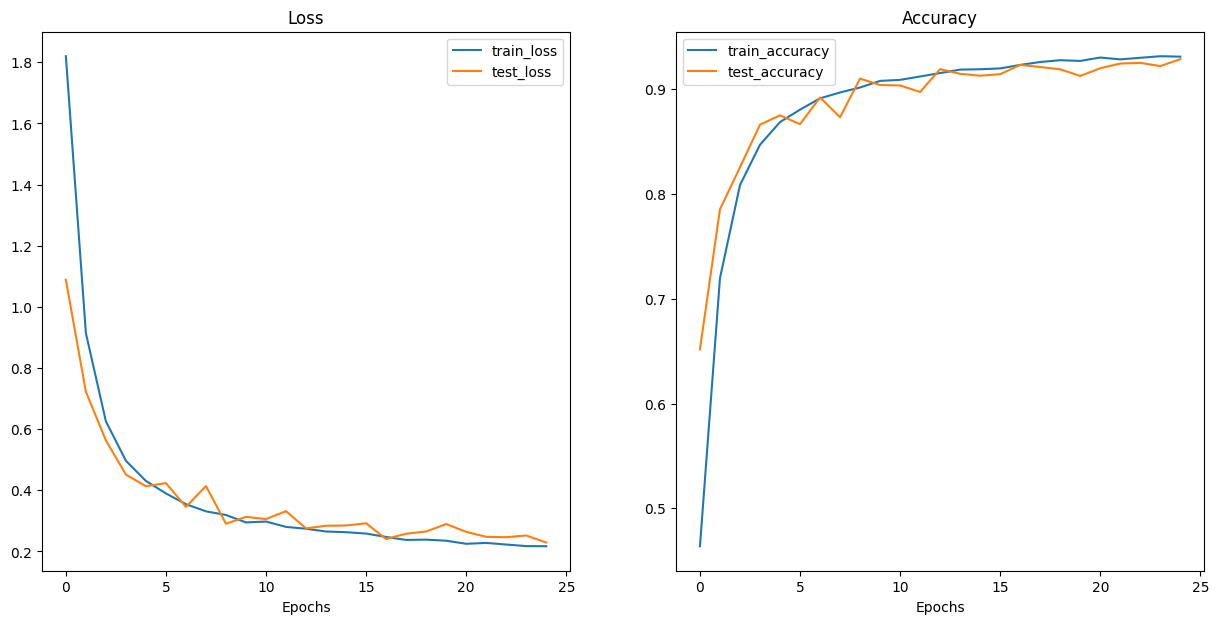

In [ ]:
plot_loss_curves(model_0_results)

### **test**

In [ ]:
csv_path = os.path.join(path,"Test.csv")


In [ ]:
class GTSRBDatasetFromDF(Dataset):
    def __init__(self,
                 df: pd.DataFrame,
                 base_path: str,
                 transform=None) -> None:

        self.df = df
        self.base_path = base_path
        self.transform = transform

        self.classes = sorted(self.df['ClassId'].unique())
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
        img = self.load_image(index)
        label = self.df.iloc[index]['ClassId']
        class_idx = self.class_to_idx[label]

        if self.transform:
            return self.transform(img), class_idx
        else:
            return img, class_idx

    def load_image(self, index: int) -> Image.Image:
        rel_path = self.df.iloc[index]['Path']
        image_path = os.path.join(self.base_path, rel_path)
        return Image.open(image_path)

dataset = GTSRBDatasetFromDF(df_test, path, transform=data_transform_test)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import torch

def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device: torch.device):

    model.eval()
    test_loss, test_acc = 0, 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)

            y_pred = model(X)

            loss = loss_fn(y_pred, y)
            test_loss += loss.item()

            pred_labels = y_pred.argmax(dim=1)
            test_acc += (pred_labels == y).sum().item() / len(pred_labels)

            all_preds.extend(pred_labels.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)

    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    return {
        'test_loss': test_loss,
        'test_acc': test_acc,
        'test_precision': precision,
        'test_recall': recall,
        'test_f1': f1
    }

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_metrics = test_step(model=model,
                        dataloader=test_dataloader,
                        loss_fn=loss_fn,
                        device=device)

print(f"Test Loss: {test_metrics['test_loss']:.4f}")
print(f"Test Accuracy: {test_metrics['test_acc']:.4f}")
print(f"Test Precision: {test_metrics['test_precision']:.4f}")
print(f"Test Recall: {test_metrics['test_recall']:.4f}")
print(f"Test F1-Score: {test_metrics['test_f1']:.4f}")

Test Loss: 0.2417
Test Accuracy: 0.9238
Test Precision: 0.9334
Test Recall: 0.9246
Test F1-Score: 0.9272
